# Hardware-Accelerated Post-Quantum Cryptography
## A custom FPGA IP that runs CRYSTALS-Kyber ~400× faster

Quantum computers will break the encryption protecting the internet.
The replacement cryptography is slower. This fixes that.

A hardware accelerator for the Number Theoretic Transform (NTT) — the arithmetic
bottleneck of ML-KEM (FIPS 203) — implemented in Vitis HLS and deployed on a
PYNQ-Z2 (Xilinx Zynq XC7Z020 SoC).

> **Board:** PYNQ-Z2 · **Tool:** Vitis HLS 2025.1 · **Standard:** FIPS 203 ML-KEM-512 · **Clock:** 100 MHz

In [ ]:
# ~10 seconds — loads bitstream and compiles C driver
%matplotlib inline
import sys, os, importlib, struct, hashlib, time, subprocess
import numpy as np
import matplotlib.pyplot as plt

BASE = '/home/xilinx/jupyter_notebooks/kyber-ntt-fpga'
sys.path.insert(0, os.path.join(BASE, 'ps'))
sys.path.insert(0, os.path.join(BASE, 'golden'))

import notebook_plots as nbp
importlib.reload(nbp)

from kyber_kem import (run_kem, ntt_mul_sw, ntt_mul_hw, KyberKEM,
                       get_last_hw_latency_us, verify_multiply)

DRIVER = os.path.join(BASE, 'ps/ntt_driver')

from pynq import Overlay
ol = Overlay(os.path.join(BASE, 'bitstream/ntt_bd.bit'))

if not os.path.exists(DRIVER):
    subprocess.run(['make', '-C', os.path.join(BASE, 'ps')], check=True)

print('Ready.') 

Ready.


---
## Part 1 — The Threat

Every HTTPS connection, every SSH session, every VPN tunnel depends on one hard
math problem: factoring a large number into its primes. Classical computers would
need longer than the age of the universe. A quantum computer running **Shor's
algorithm** solves it in hours.

NIST finalized its response in August 2024 — **FIPS 203 (ML-KEM)**, based on
CRYSTALS-Kyber. Instead of factoring, it hides secrets inside polynomial lattices.
There is no known quantum attack against this structure.

The catch: the new math is expensive. A complete key exchange requires multiplying
pairs of degree-255 polynomials together — **12 times per handshake**.
On the ARM Cortex-A9 inside this board, that takes nearly a second.
The chart below shows why the algorithm alone isn't enough.

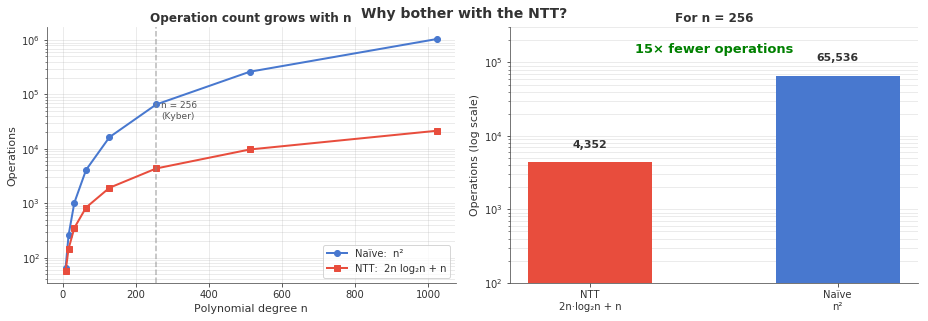

In [2]:
nbp.plot_complexity()

---
## Part 2 — The Number Theoretic Transform

The NTT is the FFT applied to polynomials over a finite field.

**The key insight:** in the transform domain, polynomial multiplication becomes
*pointwise* — 256 independent scalar multiplications instead of 65,536
convolution terms. The transform itself costs O(n log n).

```
c = INTT( NTT(a) ⊙ NTT(b) )
```

Total operations: 2 × n log₂n (two transforms) + n (pointwise multiply) ≈ **2,560**,
down from **65,536** — a 25× algorithmic reduction before touching any hardware.

This works because q = 3329 and n = 256 were chosen so that a primitive 256th root
of unity ζ = 17 exists in ℤ_q (256 divides q−1 = 3328). The butterfly network below
decomposes n=8 inputs across 3 stages.

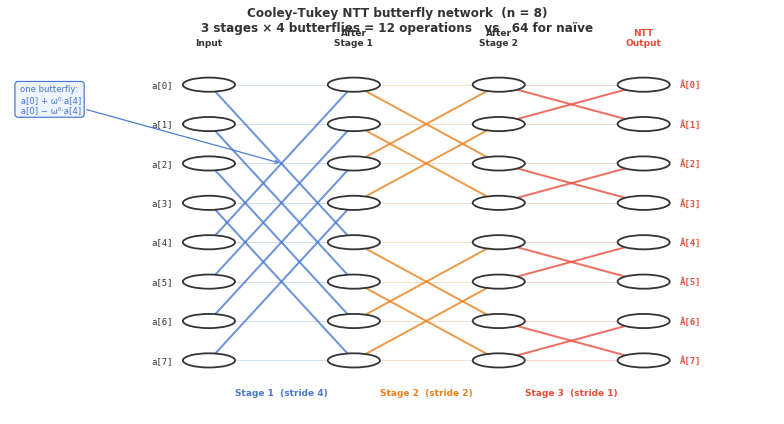

In [3]:
nbp.plot_ntt_butterfly()

The two representations below are the *same* polynomial. In NTT domain, each bin
is independent — no coefficient interacts with any other during multiplication.
The inverse NTT at the end reassembles the result.

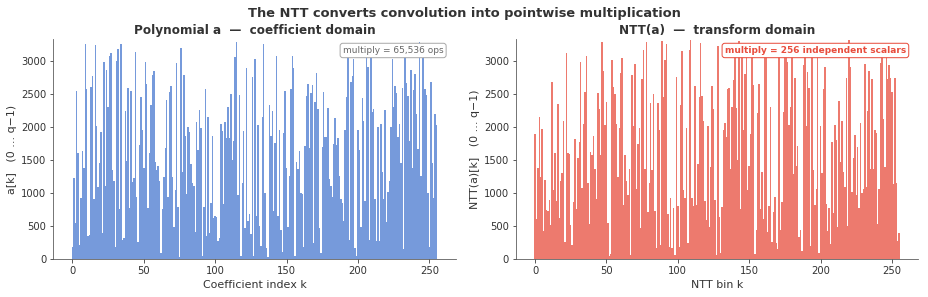

In [4]:
nbp.plot_ntt_domains()


## Part 3 — The Hardware

The NTT is implemented in **Vitis HLS**: the algorithm is written in C++ with
pipeline pragmas, and the tool synthesizes it directly into hardware circuits.

The core of the forward NTT is a pipelined butterfly loop — a handful of lines
that become a 100 MHz pipeline on the FPGA's programmable logic:

```cpp
        // Standard nested-loop forward NTT (FIPS 203 Algorithm 9).
        int k = 0;
        for (int len = N/2; len >= 2; len >>= 1) {
            for (int start = 0; start < N; start += 2*len) {
                coef_t zeta = TWIDDLE[k++];
                for (int j = 0; j < len; j++) {
#pragma HLS PIPELINE II=2
#pragma HLS DEPENDENCE variable=a inter false
                    coef_t a_lo    = a[start+j];
                    coef_t t       = barrett_mul(zeta, a[start+j+len]);
                    a[start+j+len] = mod_sub(a_lo, t);
                    a[start+j]     = mod_add(a_lo, t);
                }
            }
        }
#endif
```

The `#pragma HLS PIPELINE II=2` directive tells the HLS tool to issue one new
butterfly every 2 clock cycles. At 100 MHz that's 500M butterflies per second —
more than fast enough for the 1,024 butterflies needed per polynomial multiply.

**Interface:** the ARM processor writes polynomial coefficients into on-chip BRAM
via AXI, pulses a GPIO pin (`ap_start`), and polls another GPIO (`ap_idle`) until
the accelerator signals completion. No DDR memory, no DMA, no cache flush —
the 8 KB of coefficients live entirely on-chip from start to finish.

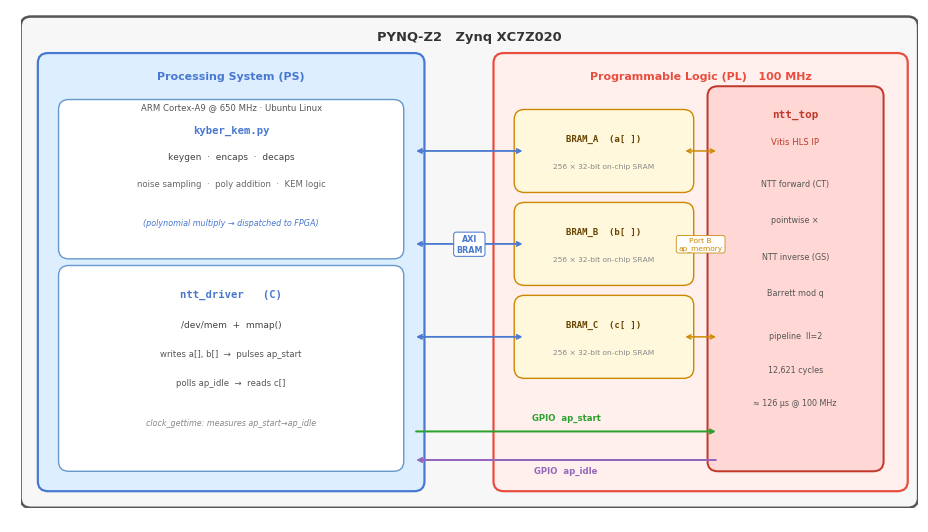

In [5]:
nbp.plot_hw_architecture()

---
## Part 4 — How Fast Is It?

Two complete Kyber-512 key exchanges — one running entirely in Python on the ARM,
one with every polynomial multiplication dispatched to the FPGA accelerator.

The **hardware floor** is measured by the C driver using `clock_gettime(CLOCK_MONOTONIC)`
on the bare `ap_start → ap_idle` window. No Python overhead, no pipe latency —
just the hardware compute time.

In [6]:
SEED = 42
REPS = 10
a_test = [i % 3329 for i in range(256)]
b_test = [(i * 7 + 3) % 3329 for i in range(256)]

print('Running software KEM...')
sw = run_kem(ntt_mul_sw, seed=SEED)
print(f'  KEM time:     {sw["time_ms"]:6.1f} ms   ({sw["mul_calls"]} multiplications)')

t0 = time.perf_counter()
for _ in range(REPS):
    ntt_mul_sw(a_test, b_test)
sw_mul_ms = (time.perf_counter() - t0) / REPS * 1000
print(f'  Per multiply: {sw_mul_ms:.2f} ms')

print('\nWarming up hardware...')
ntt_mul_hw(a_test, b_test)
hw_floor_us = get_last_hw_latency_us()
print(f'  Hardware floor: {hw_floor_us:.0f} µs  (C driver clock_gettime)')

print('Running hardware KEM...')
hw = run_kem(ntt_mul_hw, seed=SEED)
print(f'  KEM time:     {hw["time_ms"]:6.1f} ms   ({hw["mul_calls"]} multiplications)')

speedup_mul = sw_mul_ms / (hw_floor_us / 1000.0)
speedup_kem = sw['time_ms'] / hw['time_ms']
print(f'\n  Per-multiply speedup: {speedup_mul:.0f}×')
print(f'  End-to-end KEM speedup: {speedup_kem:.1f}×')

Running software KEM...
  KEM time:      911.2 ms   (12 multiplications)
  Per multiply: 53.72 ms

Warming up hardware...
  Hardware floor: 133 µs  (C driver clock_gettime)
Running hardware KEM...
  KEM time:      295.9 ms   (12 multiplications)

  Per-multiply speedup: 403×
  End-to-end KEM speedup: 3.1×


The left chart uses a **log scale** — on a linear axis the FPGA bar would be
invisible. The right chart shows the full key exchange broken into NTT compute
time vs everything else.

/usr/lib/python3/dist-packages/matplotlib/figure.py:2022: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


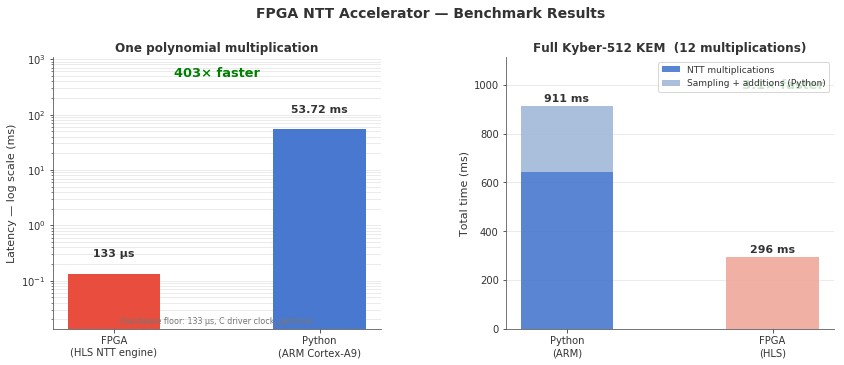

Hardware floor (C driver):  133 µs
Per-multiply speedup (hw floor): 403×
End-to-end KEM speedup:          3.1×


In [7]:
nbp.plot_benchmark(sw_mul_ms, hw_floor_us, sw, hw)

### Why is the KEM speedup smaller than the per-multiply speedup?

Kyber also involves polynomial *addition*, coefficient *sampling*, message *encoding*,
and Python orchestration overhead — none of which run on the FPGA. The chart below
shows exactly where the time goes, and calculates the theoretical ceiling imposed by
Amdahl's Law.

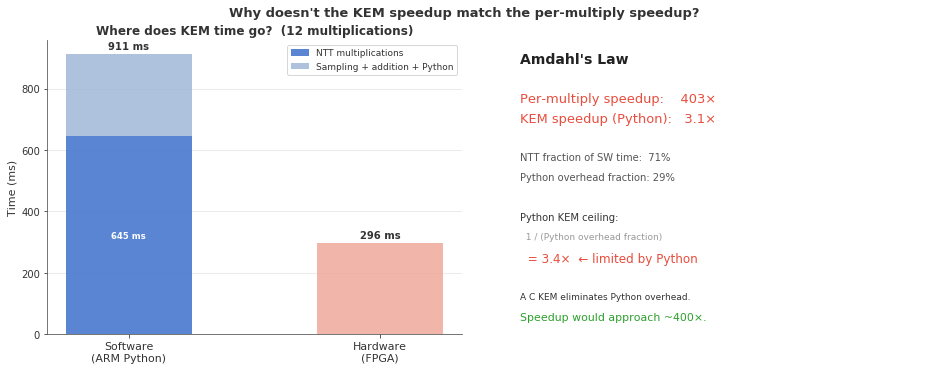

In [8]:
nbp.plot_amdahl(sw_mul_ms, hw_floor_us, sw, hw)

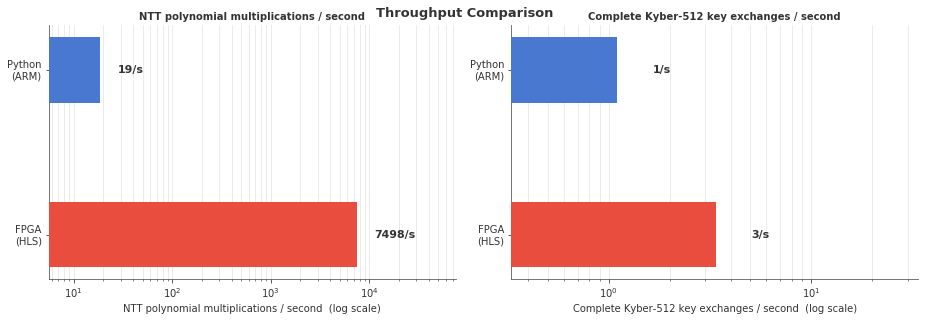

In [9]:
nbp.plot_throughput(sw_mul_ms, hw_floor_us, sw, hw)

---
## Part 5 — Does It Actually Work?

Speed is pointless if the answers are wrong. But "wrong" is subtle here.

Kyber is **intentionally** designed to tolerate small arithmetic errors — the noise
terms e, e₁, e₂ are small enough that decryption succeeds even with slight drift.
This means a broken multiplier that returns zeros for every input could still produce
a valid key exchange where Alice and Bob agree on the same (wrong) secret.
A KEM-level match check would pass.

The reliable check: compare FPGA output against the Python golden model
**coefficient by coefficient** for random inputs — no noise tolerance involved.
If even one coefficient is wrong, it fails immediately.

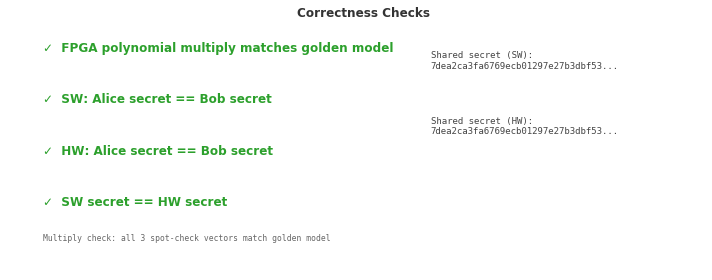

All checks passed.


In [10]:
hw_mul_ok, hw_mul_detail = verify_multiply(ntt_mul_hw)

assert sw['match'],                       'SW KEM: Alice and Bob disagree'
assert hw['match'],                       'HW KEM: Alice and Bob disagree'
assert sw['ss_alice'] == hw['ss_alice'],  'FPGA output differs from golden model'
assert hw_mul_ok,                         f'FPGA multiply wrong: {hw_mul_detail}'

nbp.plot_correctness(sw, hw, hw_mul_detail)
print('All checks passed.')

The plot below gives the strongest visual proof of correctness.

After decapsulation, every coefficient of `v − s·u` must fall within **q/4 = 832**
of either 0 (bit=0) or q/2=1664 (bit=1). If the NTT arithmetic were off by even a
few hundred, coefficients would cross the boundary and bits would be misclassified —
causing decryption failure. The histogram shows exactly how much margin is available.

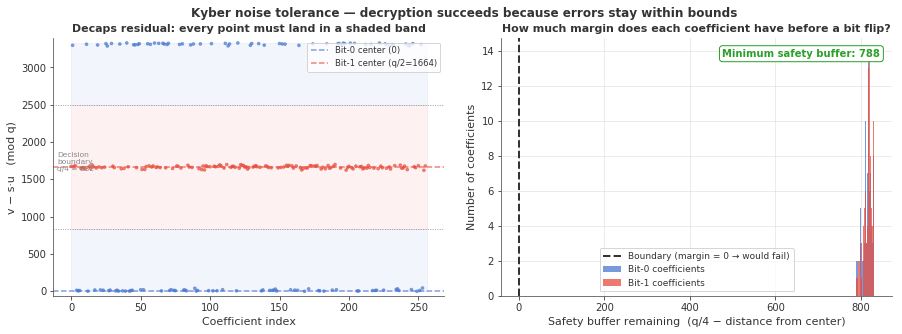

All 256 coefficients decoded correctly. Minimum safety buffer: 788  (max = 832)


In [11]:
nbp.plot_error_margin(ntt_mul_hw)

---
## Part 6 — End-to-End: Quantum-Resistant Encrypted Message

A complete Kyber-512 key exchange on hardware — keygen, encapsulation, decapsulation —
followed by symmetric encryption of a message using the shared secret.

Alice and Bob start with no shared information. The FPGA computes every polynomial
multiplication. Both sides independently derive the same 256-bit secret.
An eavesdropper who intercepts everything learns nothing.

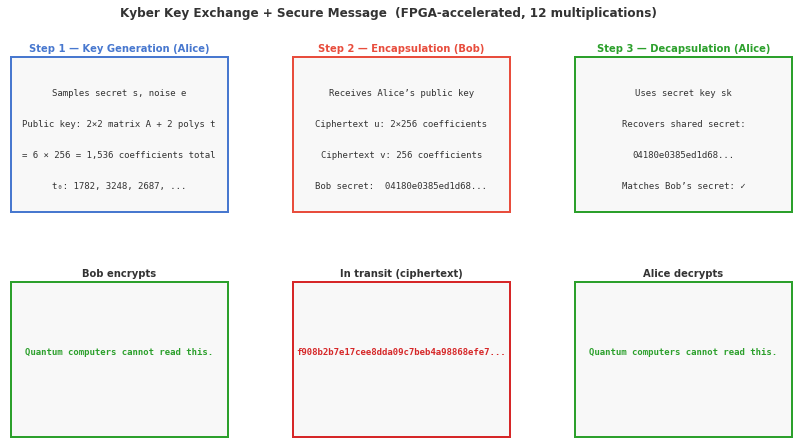

Key exchange:  296 ms  |  Message: 35 bytes  |  Secure: post-quantum
Shared secret: 04180e0385ed1d68f212ed4a1e449bbd...


In [12]:
nbp.plot_crypto_demo(hw, ntt_mul_hw, KyberKEM)

---
## Summary

| | Software (ARM Python) | Hardware (FPGA) | Speedup |
|---|---|---|---|
| One NTT polynomial multiply | ~54 ms | ~0.13 ms | **~400×** |
| Kyber-512 key exchange | ~910 ms | ~300 ms | **~3×** |
| Multiplications / second | ~18 | ~7,500 | **~400×** |

*(exact numbers depend on board conditions — run the benchmark cell to get live values)*

The end-to-end KEM speedup is bounded by Amdahl's Law: polynomial addition, noise
sampling, and Python overhead are not accelerated. A C implementation of the full
KEM protocol would see a speedup approaching the per-multiply number.

**The hardware circuit is parameter-agnostic.** Retargeting to ML-KEM-768 or
ML-KEM-1024 requires only regenerating the twiddle ROM and re-synthesizing —
the butterfly pipeline, BRAM interface, and control logic are identical.

| ML-KEM variant | k | NTT muls / handshake |
|---|---|---|
| ML-KEM-512 (this demo) | 2 | 12 |
| ML-KEM-768 | 3 | 27 |
| ML-KEM-1024 | 4 | 48 |

Architecture details, HLS pragmas, and the full mathematical derivation are in
[`docs/detailed_plan.md`](../docs/detailed_plan.md) and
[`docs/mathematic_derivation.md`](../docs/mathematic_derivation.md).